# Pekel water mask check

The browse-image water mask (`isce2_topsapp.water_mask.get_water_mask_raster_for_browse_image`)
thresholds JRC/Pekel *water occurrence* at `>= 95` percent. Over the open ocean this looks wonky.

This notebook reproduces the mask over the GUNW used in `tests/legacy_notebooks/prepare-for-delivery.ipynb`
(Southern California / Channel Islands, track 064) and shows why.


## Config


In [1]:
from pathlib import Path

import numpy as np
import rasterio
import requests
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.transform import array_bounds
from dem_stitcher.rio_tools import reproject_arr_to_match_profile
from scipy.ndimage import binary_dilation, binary_erosion
from tile_mate import get_raster_from_tiles

GUNW_URL = (
    'https://cumulus.asf.earthdatacloud.nasa.gov/ARIA/SENTINEL-1_INTERFEROGRAMS/'
    'S1-GUNW-A-R-064-tops-20210723_20210711-015001-35393N_33512N-PP-6267-v2_0_4/'
    'S1-GUNW-A-R-064-tops-20210723_20210711-015001-35393N_33512N-PP-6267-v2_0_4.nc'
)
REPO_ROOT = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / 'isce2_topsapp').is_dir())
GUNW_PATH = REPO_ROOT / GUNW_URL.split('/')[-1]

OCC_THRESHOLD = 95
OCC_NODATA = 255
THRESHOLD_SWEEP = [95, 90, 80, 50, 30, 10]

FIGSIZE = (11, 6)
FIGSIZE_WIDE = (18, 9)
OCC_CMAP = 'turbo'
MASK_CMAP = ListedColormap(['#2b2b3d', '#ffd23f'])
ZOOM = (slice(1500, None), slice(0, 1700))
NODATA_DILATION = 3

In [2]:
if not GUNW_PATH.exists():
    GUNW_PATH.write_bytes(requests.get(GUNW_URL).content)
GUNW_PATH

PosixPath('/Users/cmarshak/bekaert-team/DockerizedTopsApp/S1-GUNW-A-R-064-tops-20210723_20210711-015001-35393N_33512N-PP-6267-v2_0_4.nc')

## Target grid (browse image grid)


In [3]:
with rasterio.open(f'netcdf:{GUNW_PATH}:/science/grids/data/connectedComponents') as ds:
    profile = ds.profile

extent = array_bounds(profile['height'], profile['width'], profile['transform'])
extent

(-119.10791666666667, 33.51125, -115.91791666666667, 35.39375)

## Raw Pekel occurrence tiles


In [4]:
X_occ, p_occ = get_raster_from_tiles(extent, tile_shortname='pekel_water_occ_2021')
X_occ = X_occ[0, ...]
X_occ.shape, X_occ.dtype, p_occ['nodata']

Reading tile metadata:   0%|          | 0/1 [00:00<?, ?it/s]

Reading tile metadata: 100%|██████████| 1/1 [00:00<00:00, 121.45it/s]

Reading tile imagery:   0%|          | 0/1 [00:00<?, ?it/s]

Reading tile imagery: 100%|██████████| 1/1 [00:00<00:00,  1.18it/s]

Reading tile imagery: 100%|██████████| 1/1 [00:00<00:00,  1.18it/s]

((7530, 12761), dtype('uint8'), None)

`tile_mate` returns `nodata=None`, but the JRC surface-water product encodes **no-data as 255**.
Any comparison of the form `X >= threshold` therefore silently classifies no-data as water.


In [5]:
values, counts = np.unique(X_occ, return_counts=True)
top = sorted(zip(values.tolist(), counts.tolist()), key=lambda t: -t[1])[:12]
print(f'{"value":>6} {"count":>12}')
[print(f'{v:>6} {c:>12}') for v, c in top]
print()
print('n == 255 (nodata):', int((X_occ == OCC_NODATA).sum()))
print('n >= 95 (incl. nodata):', int((X_occ >= OCC_THRESHOLD).sum()))

 value        count
     0     88128962
   255      1549420
    97      1242356
    98      1138691
    96      1133612
    95       970888
    94       563450
    93       427567
    92       329569
    91       138311
    99       131350
    90        31817

n == 255 (nodata): 1549420
n >= 95 (incl. nodata): 6166390


## Distribution of the *valid* occurrence values


percentiles [1, 5, 10, 25, 50, 75, 90]: [ 5. 90. 92. 94. 96. 97. 98.]
fraction of valid water-ish pixels in [90, 95): 0.23249003267025872


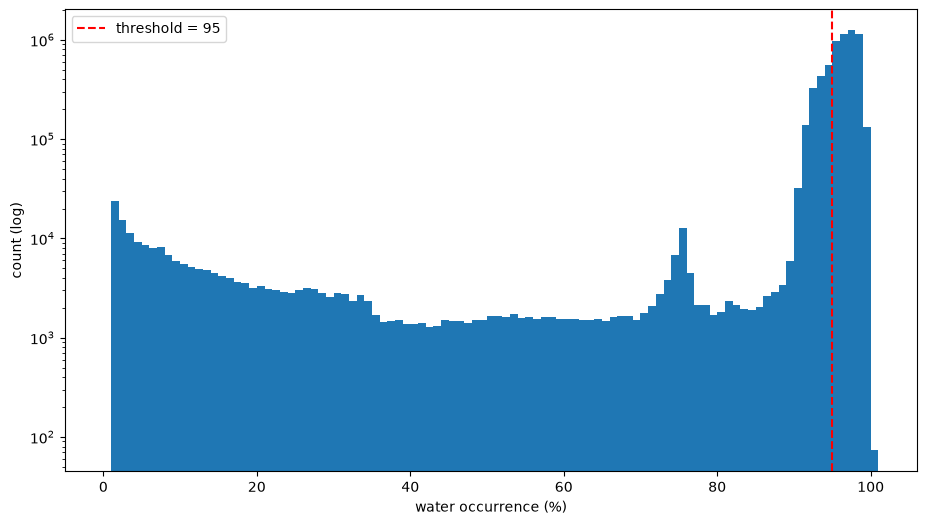

In [6]:
occ_valid = X_occ[(X_occ != OCC_NODATA) & (X_occ > 0)]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(occ_valid, bins=np.arange(0, 102), log=True)
ax.axvline(OCC_THRESHOLD, color='red', ls='--', label=f'threshold = {OCC_THRESHOLD}')
ax.set_xlabel('water occurrence (%)')
ax.set_ylabel('count (log)')
ax.legend()

print('percentiles [1, 5, 10, 25, 50, 75, 90]:', np.percentile(occ_valid, [1, 5, 10, 25, 50, 75, 90]))
print('fraction of valid water-ish pixels in [90, 95):', float(((occ_valid >= 90) & (occ_valid < 95)).mean()))

A large mass of ocean pixels sits in **90-94**, i.e. just *below* the 95 threshold.


## Reproject to the browse grid


In [7]:
# bilinear is what the original code used, and reproduces the browse mask as delivered
X_occ_bil, _ = reproject_arr_to_match_profile(X_occ[None, ...], p_occ, profile, resampling='bilinear')
X_occ_bil = X_occ_bil[0, ...]

# nearest keeps the 255 sentinel intact, so no-data stays identifiable; used everywhere below
X_occ_r, _ = reproject_arr_to_match_profile(X_occ[None, ...], p_occ, profile, resampling='nearest')
X_occ_r = X_occ_r[0, ...]

mask_current = X_occ_bil >= OCC_THRESHOLD
X_occ_r.shape, float(mask_current.mean())

((2259, 3828), 0.06421244084384625)

Text(0.5, 1.0, 'current mask: bilinear, occ >= 95')

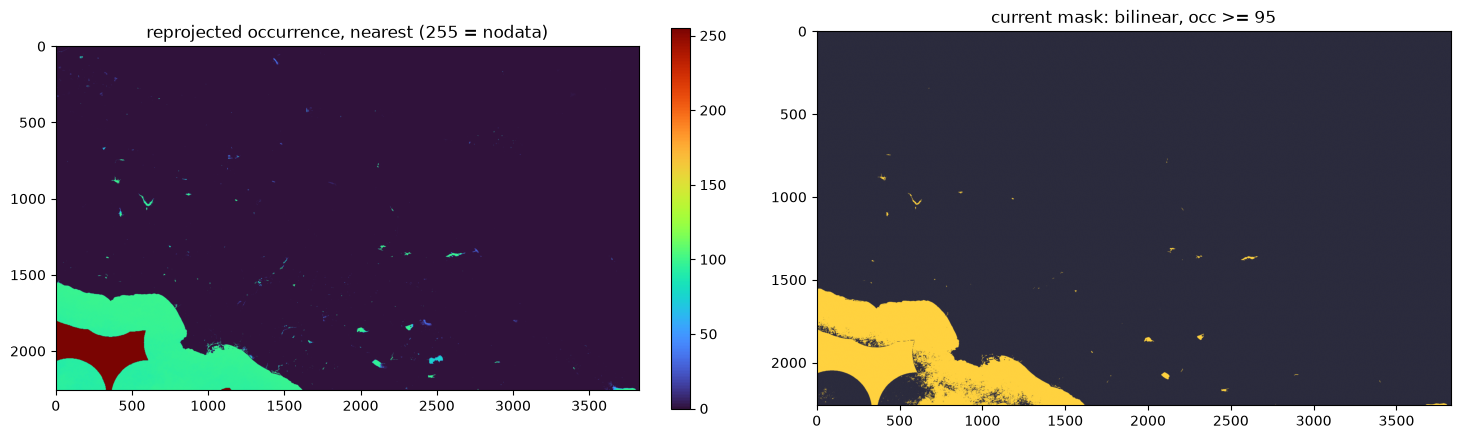

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
im = ax[0].imshow(X_occ_r, vmin=0, vmax=255, cmap=OCC_CMAP)
ax[0].set_title('reprojected occurrence, nearest (255 = nodata)')
fig.colorbar(im, ax=ax[0], fraction=0.03)
ax[1].imshow(mask_current, cmap=MASK_CMAP)
ax[1].set_title(f'current mask: bilinear, occ >= {OCC_THRESHOLD}')

## Zoom on the ocean, where it goes wrong


Text(0.5, 1.0, 'occ >= 95')

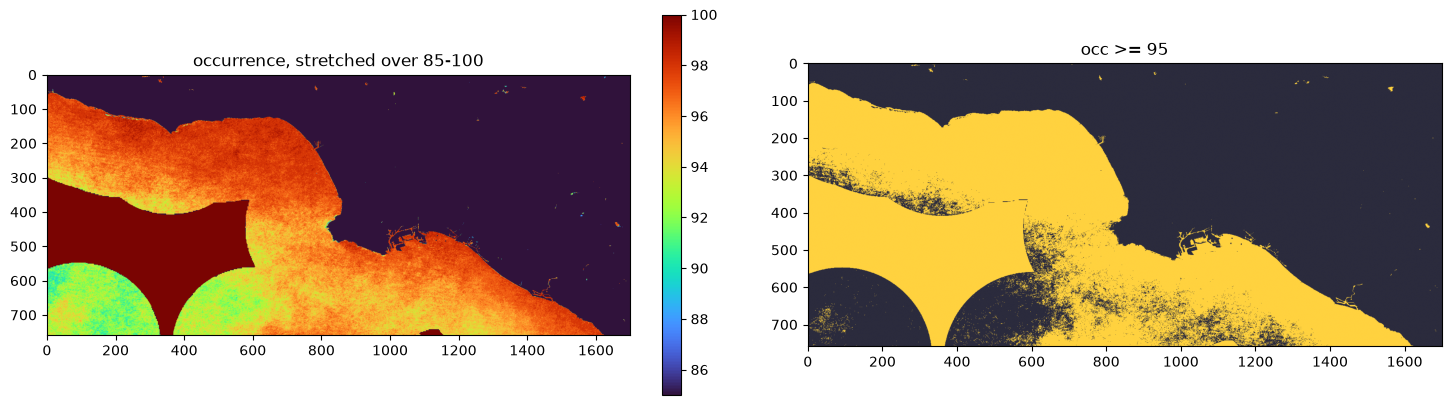

In [9]:
occ_zoom = X_occ_r[ZOOM]

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
im = ax[0].imshow(occ_zoom, vmin=85, vmax=100, cmap=OCC_CMAP)
ax[0].set_title('occurrence, stretched over 85-100')
fig.colorbar(im, ax=ax[0], fraction=0.03)
ax[1].imshow(occ_zoom >= OCC_THRESHOLD, cmap=MASK_CMAP)
ax[1].set_title(f'occ >= {OCC_THRESHOLD}')

Two artifacts:

1. **Scalloped bites out of the open ocean.** Landsat WRS-2 scene footprints have different
   observation counts, so open water dithers between ~90 and 100 percent occurrence. The
   scene-edge arcs fall to 90-94 and get dropped by the 95 threshold.
2. **Salt-and-pepper in the surf / shallow-water zone**, where occurrence is genuinely lower.

Note also the large 255 block offshore: that is *no-data*, and it is only classified as
water by accident, because `255 >= 95`.


## Threshold sweep


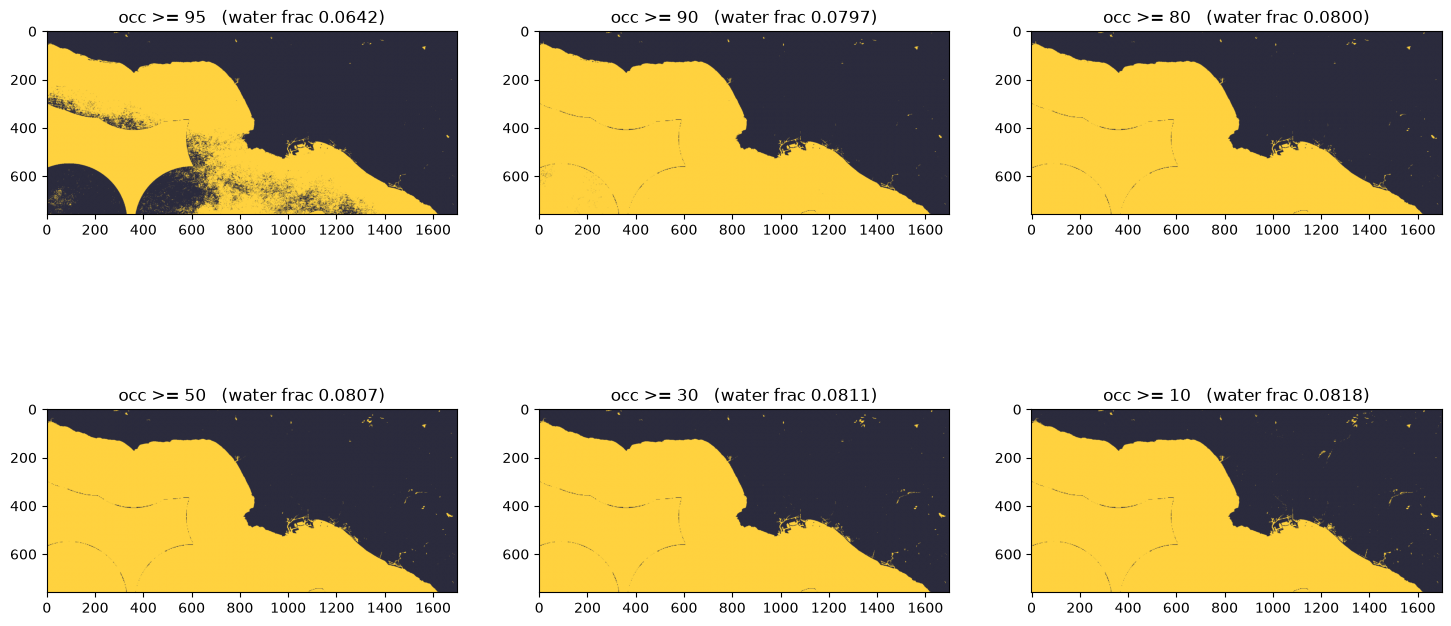

In [10]:
fig, ax = plt.subplots(2, 3, figsize=FIGSIZE_WIDE)
for a, t in zip(ax.ravel(), THRESHOLD_SWEEP):
    m = X_occ_r >= t
    a.imshow(m[ZOOM], cmap=MASK_CMAP)
    a.set_title(f'occ >= {t}   (water frac {m.mean():.4f})')

Everything at or below **90** gives a solid ocean and a clean coastline; only the thin
scene-boundary hairlines remain. Between 90 and 10 the water fraction moves by <0.4 percent,
so the mask is insensitive to the exact value once you are below 95 — 95 sits right on the cliff.


## The no-data rim


The 255 no-data blocks are offshore, so calling them water is right here. But the source
carries a thin rim of **0-occurrence** pixels along the no-data edge, and 0 reads as land.
That rim is what draws the hairline seams still visible through the ocean at `>= 90`.

Growing the no-data region a few pixels with `binary_dilation` swallows the rim. It is
targeted: it touches only no-data edges, so the coastline is untouched.


In [11]:
nodata = X_occ_r == OCC_NODATA
base = ((X_occ_r >= 90) & ~nodata) | nodata

# holes strictly inside the ocean, i.e. not the land/coast side of the mask
ocean_core = binary_erosion(base, iterations=25)
interior = binary_dilation(ocean_core, iterations=30)
holes = ~base & interior

print('interior hole pixels:', int(holes.sum()))
for d in [1, 2, 3, 4, 5]:
    near = holes & binary_dilation(nodata, iterations=d)
    print(f'  within {d}px of nodata: {int(near.sum()):>6}  ({near.sum() / holes.sum():.1%})')

interior hole pixels: 8166
  within 1px of nodata:    872  (10.7%)
  within 2px of nodata:   1310  (16.0%)


  within 3px of nodata:   1429  (17.5%)
  within 4px of nodata:   1444  (17.7%)
  within 5px of nodata:   1445  (17.7%)


So roughly **18 percent** of the interior holes are the no-data rim, and a 3 pixel dilation
captures essentially all of them (going to 4 or 5 adds almost nothing). The remaining ~82
percent are genuine low-occurrence pixels further out along the Landsat scene seams — the
dilation does not claim to fix those, and they are 1-2 px dashed lines rather than the
scalloped bites the old 95 threshold produced.


base water frac:     0.07968046541339575
dilated water frac:  0.07985508332396642
pixels added:        1510
interior holes left: 6737


Text(0.5, 1.0, 'added pixels')

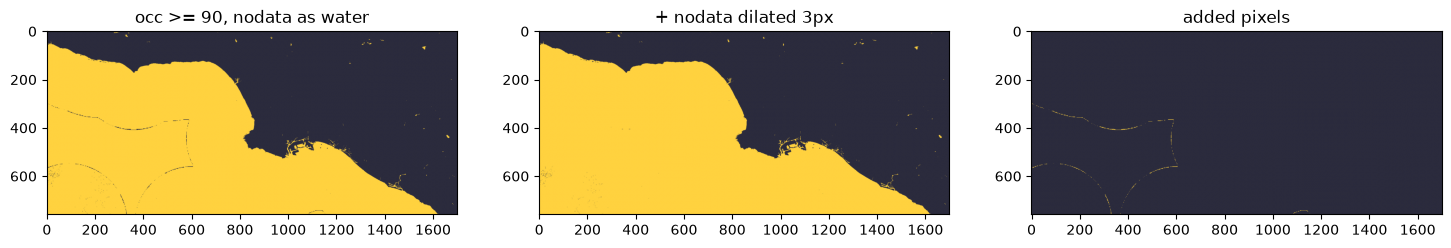

In [12]:
mask_dilated = base | binary_dilation(nodata, iterations=NODATA_DILATION)

print('base water frac:    ', float(base.mean()))
print('dilated water frac: ', float(mask_dilated.mean()))
print('pixels added:       ', int(mask_dilated.sum() - base.sum()))
print('interior holes left:', int((~mask_dilated & interior).sum()))

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(base[ZOOM], cmap=MASK_CMAP)
ax[0].set_title('occ >= 90, nodata as water')
ax[1].imshow(mask_dilated[ZOOM], cmap=MASK_CMAP)
ax[1].set_title(f'+ nodata dilated {NODATA_DILATION}px')
ax[2].imshow((mask_dilated != base)[ZOOM], cmap=MASK_CMAP)
ax[2].set_title('added pixels')

For contrast, dilating the *whole* mask by 3 px would also close the seams, but it grows
the coastline ~270 m into land, which is an order of magnitude more pixels for an artifact
that only lives at no-data edges.


nodata-only dilation adds: 1510
whole-mask dilation adds:  26688


Text(0.5, 1.0, 'whole-mask dilation, added pixels')

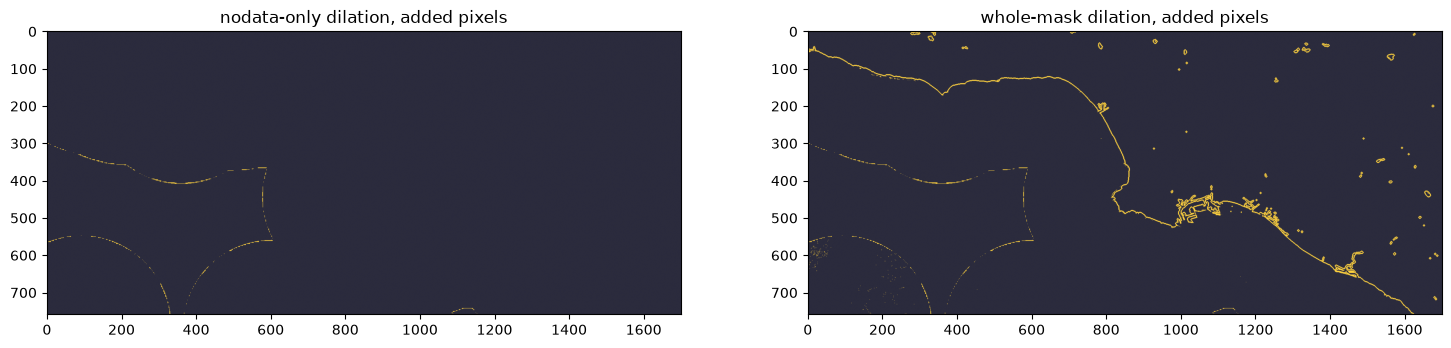

In [13]:
mask_dilate_all = binary_dilation(base, iterations=NODATA_DILATION)

print('nodata-only dilation adds:', int(mask_dilated.sum() - base.sum()))
print('whole-mask dilation adds: ', int(mask_dilate_all.sum() - base.sum()))

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].imshow((mask_dilated != base)[ZOOM], cmap=MASK_CMAP)
ax[0].set_title('nodata-only dilation, added pixels')
ax[1].imshow((mask_dilate_all != base)[ZOOM], cmap=MASK_CMAP)
ax[1].set_title('whole-mask dilation, added pixels')

## Candidate fix


current water frac: 0.06421244084384625
proposed water frac: 0.07985508332396642


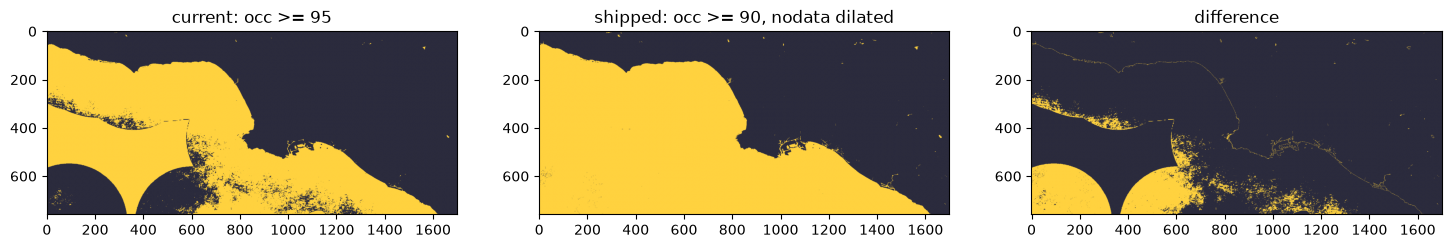

In [14]:
from isce2_topsapp.water_mask import water_mask_from_occurrence

mask_fixed = water_mask_from_occurrence(X_occ_r)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(mask_current[ZOOM], cmap=MASK_CMAP)
ax[0].set_title(f'current: occ >= {OCC_THRESHOLD}')
ax[1].imshow(mask_fixed[ZOOM], cmap=MASK_CMAP)
ax[1].set_title('shipped: occ >= 90, nodata dilated')
ax[2].imshow((mask_fixed != mask_current)[ZOOM], cmap=MASK_CMAP)
ax[2].set_title('difference')

print('current water frac:', float(mask_current.mean()))
print('proposed water frac:', float(mask_fixed.mean()))

## Notes on the resampling

`reproject_arr_to_match_profile(..., resampling='bilinear')` averages the 255 no-data code
with real 0-100 values, so a halo of bogus intermediate occurrence appears around every
no-data edge, and it erodes the 255 sentinel so the no-data dilation above can no longer
find it. `nearest` is what the shipped code uses.


nodata pixels, nearest:  139400
nodata pixels, bilinear: 137748


Text(0.5, 1.0, 'nearest')

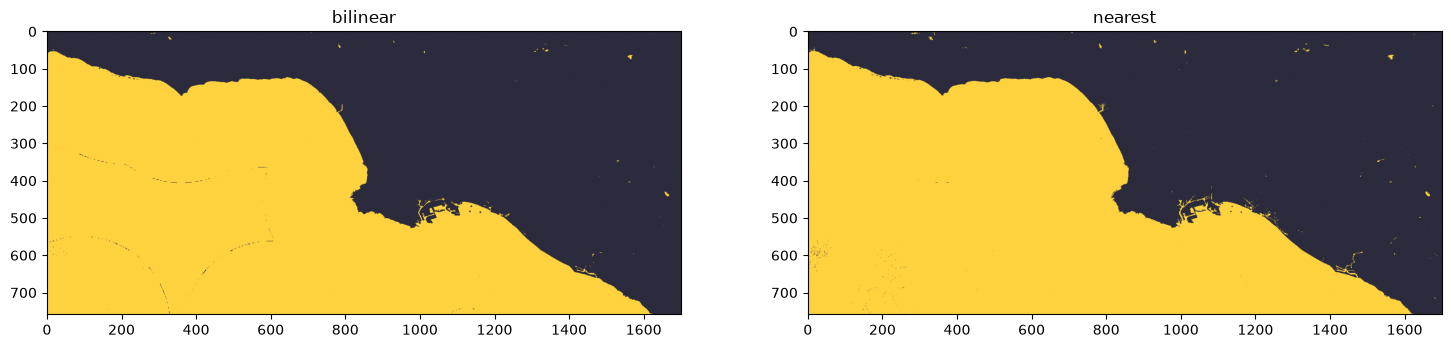

In [15]:
print('nodata pixels, nearest: ', int((X_occ_r == OCC_NODATA).sum()))
print('nodata pixels, bilinear:', int((X_occ_bil == OCC_NODATA).sum()))

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].imshow(water_mask_from_occurrence(X_occ_bil)[ZOOM], cmap=MASK_CMAP)
ax[0].set_title('bilinear')
ax[1].imshow(water_mask_from_occurrence(X_occ_r)[ZOOM], cmap=MASK_CMAP)
ax[1].set_title('nearest')

## Summary

- The `>= 95` threshold in `isce2_topsapp/water_mask.py` (and the identical `>= 95` in
  `isce2_topsapp/localize_mask.py`) is the cause. Open ocean in JRC/Pekel occurrence is not
  uniformly 100 percent; Landsat scene-footprint edges sit at 90-94 and get carved out.
- JRC no-data (255) is being read as water only because `255 >= 95`. That is not intentional
  and it survives only as long as the threshold is `<= 255`.
- Dropping the threshold to ~90 and masking 255 explicitly restores a solid ocean.
- The 255 blocks carry a rim of 0-occurrence pixels that reads as land; dilating no-data by
  3 px swallows the rim for ~1.5k extra pixels, without moving the coastline.
